In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
%pip install lightgbm
from lightgbm import LGBMRegressor

# Deep Learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [31]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [32]:
df = pd.read_csv('data.csv')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6315 entries, 0 to 6314
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6315 non-null   object 
 1   Open    6315 non-null   float64
 2   High    6315 non-null   float64
 3   Low     6315 non-null   float64
 4   Close   6315 non-null   float64
dtypes: float64(4), object(1)
memory usage: 246.8+ KB


In [34]:
df.head()

,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.2
1,2000-01-04,1594.40,1641.95,1594.40,1638.7
2,2000-01-05,1634.55,1635.50,1555.05,1595.8
3,2000-01-06,1595.80,1639.00,1595.80,1617.6
4,2000-01-07,1616.60,1628.25,1597.20,1613.3


In [35]:
df.describe()

,Open,High,Low,Close
count,6315.000000,6315.000000,6315.000000,6315.000000
mean,7813.645732,7858.810665,7758.153325,7809.684806
std,6248.404053,6270.434420,6216.988574,6244.654057
min,853.000000,877.000000,849.950000,854.200000
25%,2851.375000,2884.100000,2812.650000,2850.600000
50%,5803.050000,5857.350000,5749.500000,5796.900000
75%,10786.175000,10830.625000,10727.775000,10781.725000
max,26248.250000,26277.350000,26151.400000,26216.050000


### Part 1: Data Understanding and Preprocessing
1. Download the dataset from the provided Kaggle link.
2. Perform exploratory data analysis (EDA):
- Plot stock price trends for a few companies.
- Identify missing values and handle them.
- Normalize/scale the data if necessary.
3. Decide which variable(s) you want to predict( Daily, Weekly, Monthly)
- Close price (most common target).
- Optionally, you can also try next day return or percentage change.

In [36]:
# Converting Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

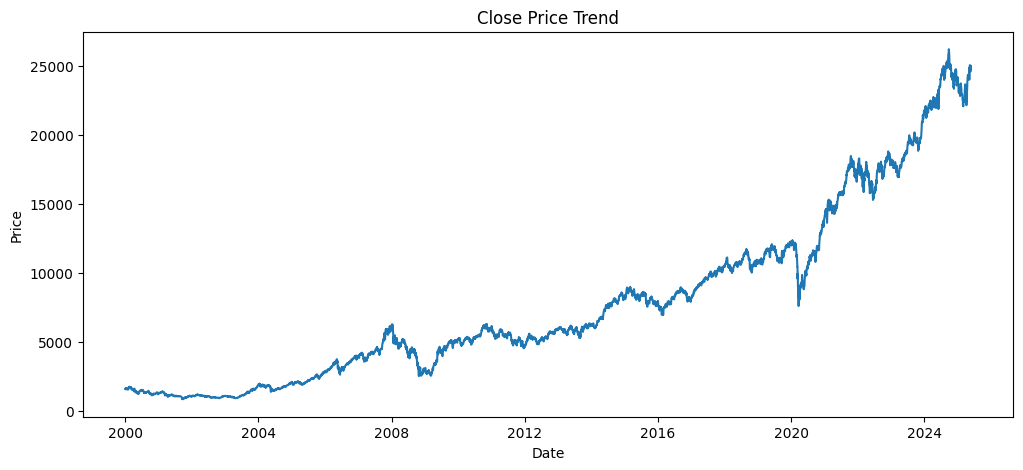

In [37]:
# Plotting Stock Prices
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Close Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [38]:
# Finding Missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Open     0
High     0
Low      0
Close    0
dtype: int64


In [39]:
# Feature engineering
# We are creating new useful features (inputs) from raw stock data so that our model can learn better patterns.

# Returns - This calculates percentage change in price from previous day
# Shows daily gain/loss and helps model understand momentum
df['Return'] = df['Close'].pct_change()

# Moving averages
df['SMA_10'] = df['Close'].shift(1).rolling(10).mean() # Average of last 10 days
df['SMA_50'] = df['Close'].shift(1).rolling(50).mean() # Average of last 50 days

# Volatility - Standard deviation of last 10 days returns
# High value indicates price is jumping a lot
# Low value indicates stable market
df['Volatility'] = df['Return'].shift(1).rolling(10).std()
df['EMA_10'] = df['Close'].shift(1).ewm(span=10, adjust=False).mean()

# RSI
delta = df['Close'].shift(1).diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Bollinger Bands
df['BB_Middle'] = df['Close'].shift(1).rolling(20).mean()
df['BB_Upper'] = df['BB_Middle'] + 2 * df['Close'].shift(1).rolling(20).std()
df['BB_Lower'] = df['BB_Middle'] - 2 * df['Close'].shift(1).rolling(20).std()

df.dropna(inplace=True)

In [40]:
# Target Variable
df['Target'] = df['Close'].shift(-1) # Next day prediction
df.dropna(inplace=True)

print(f"\nFinal dataset shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
# It moves the column up by 1 row
# So, today’s row will contain tomorrow’s closing price


Final dataset shape: (6264, 14)
Date range: 2000-03-14 00:00:00 to 2025-05-23 00:00:00


In [41]:
df.head()

,Open,High,Low,Close,Return,SMA_10,SMA_50,Volatility,EMA_10,RSI,BB_Middle,BB_Upper,BB_Lower,Target
Date,,,,,,,,,,,,,,
2000-03-14,1561.55,1571.30,1503.20,1567.0,0.004037,1658.71,1650.120,0.023467,1648.473653,31.538621,1690.720,1786.664054,1594.775946,1620.1
2000-03-15,1546.80,1630.95,1538.70,1620.1,0.033886,1649.93,1649.616,0.021264,1633.660261,35.512763,1683.945,1794.422289,1573.467711,1562.2
2000-03-16,1620.40,1621.20,1554.30,1562.2,-0.035739,1640.67,1649.244,0.021034,1631.194759,37.944409,1679.395,1792.624706,1566.165294,1556.6
2000-03-21,1563.30,1585.25,1542.65,1556.6,-0.003585,1627.24,1648.572,0.023141,1618.650258,35.191847,1670.400,1790.998630,1549.801370,1589.6
2000-03-22,1551.05,1604.00,1551.05,1589.6,0.021200,1617.30,1647.352,0.022472,1607.368393,33.205102,1662.340,1790.885342,1533.794658,1553.4


### Part 2: Train-Test Splits for Robustness
To ensure fairness and robustness of models, create multiple train-test splits instead of just one.
For example:
1. Split 1 (2000–2015 training, 2016–2018 testing)
2. Split 2 (2000–2018 training, 2019–2020 testing)
3. Split 3 (2000–2020 training, 2021–2022 testing)
4. Split 4 (2000–2022 training, 2023–2024 testing)
This ensures that the model is tested on different market regimes (bullish, bearish, sideways
markets).

In [42]:
# Defining splits as given in assignment
splits = [
    ('2000-01-01','2015-12-31','2016-01-01','2018-12-31'),
    ('2000-01-01','2018-12-31','2019-01-01','2020-12-31'),
    ('2000-01-01','2020-12-31','2021-01-01','2022-12-31'),
    ('2000-01-01','2022-12-31','2023-01-01','2024-12-31')
]

In [43]:
features = ['Return', 'SMA_10', 'SMA_50', 'Volatility', 'EMA_10', 'RSI', 'BB_Upper', 'BB_Lower']
print(f"\nFeatures used: {features}")


Features used: ['Return', 'SMA_10', 'SMA_50', 'Volatility', 'EMA_10', 'RSI', 'BB_Upper', 'BB_Lower']


In [44]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

def get_split_data(df, start_train, end_train, start_test, end_test, features):
    train = df.loc[start_train:end_train]
    test = df.loc[start_test:end_test]

    X_train = train[features]
    y_train = train['Target'].values.reshape(-1, 1)
    X_test = test[features]
    y_test = test['Target'].values.reshape(-1, 1)

    # Scale features
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Keeping original features for tree models
    X_train_orig = X_train.values
    X_test_orig = X_test.values

    # Scaling target for deep learning models
    y_train_scaled = scaler_y.fit_transform(y_train).flatten()
    y_test_scaled = scaler_y.transform(y_test).flatten()

    # Tree models cannot extrapolate to prices they haven't seen during training.
    # E.g., if trained on data up to 18000, they will fail when test data hits 26000.
    # We extract today's close to later calculate the "difference" for trees.
    train_close_today = train['Close'].values
    test_close_today = test['Close'].values

    return (X_train_scaled, X_test_scaled,
            X_train_orig, X_test_orig,
            y_train_scaled, y_test_scaled,
            y_train.flatten(), y_test.flatten(),
            train_close_today, test_close_today)

### Part 3: Model Building

In [45]:
linear_models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
}

In [46]:
tree_models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=4, subsample=0.7, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.01, max_depth=4, subsample=0.7, reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1)
}

In [47]:
stack_model = StackingRegressor(
    estimators=[
        ('linear', LinearRegression()),
        ('ridge', Ridge(alpha=1.0)),
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
    ],
    final_estimator=LinearRegression()
)

all_models = {**linear_models, **tree_models, "Stacking": stack_model}

In [48]:
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [49]:
def create_gru_model(input_shape):
    model = Sequential([
        GRU(100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

### Part 4: Performance Measures
Since stock price prediction is a regression task, you should use multiple evaluation metrics:
1. Mean Absolute Error (MAE)
2. Root Mean Squared Error (RMSE)
3. Mean Absolute Percentage Error (MAPE)
4. R-Squared (Coefficient of Determination)
5. Directional Accuracy (DA)

In [50]:
def evaluate(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    true_direction = np.sign(np.diff(y_true))
    pred_direction = np.sign(np.diff(y_pred))
    min_len = min(len(true_direction), len(pred_direction))
    true_direction = true_direction[:min_len]
    pred_direction = pred_direction[:min_len]
    da = np.mean(true_direction == pred_direction) * 100
    return mae, rmse, mape, r2, da

In [51]:
def create_sequences(X, y, window=30):
    y = np.array(y)
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

### Model Training

In [52]:
# Training Loop
results = []
print("Training Models Across Different Time Splits:")

for split_no, (tr_start, tr_end, te_start, te_end) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Split {split_no + 1}: Train ({tr_start} to {tr_end}) | Test ({te_start} to {te_end})")
    print(f"{'='*60}")

    try:
        # Unpacking the two new variables
        (X_train_scaled, X_test_scaled,
         X_train_orig, X_test_orig,
         y_train_scaled, y_test_scaled,
         y_train_orig, y_test_orig,
         train_close_today, test_close_today) = get_split_data(df, tr_start, tr_end, te_start, te_end, features)

        # LINEAR MODELS
        print("\n--- Linear Models ---")
        for name, model in linear_models.items():
            print(f"Training {name}...", end=" ")
            model.fit(X_train_scaled, y_train_orig)
            preds = model.predict(X_test_scaled)
            mae, rmse, mape, r2, da = evaluate(y_test_orig, preds)
            results.append({"Split": split_no + 1, "Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "DA": da})
            print(f"R²={r2:.4f}, DA={da:.1f}%")

        # TREE MODELS
        print("\n--- Tree-Based Models ---")
        # Train trees to predict the DIFFERENCE between today and tomorrow.
        # This stops them from failing when test prices exceed training prices.
        y_train_diff = y_train_orig - train_close_today
        y_test_diff = y_test_orig - test_close_today

        for name, model in tree_models.items():
            print(f"Training {name}...", end=" ")
            model.fit(X_train_orig, y_train_diff)
            preds_diff = model.predict(X_test_orig)

            # Add today's actual close back to the predicted difference to get absolute price
            preds_orig = preds_diff + test_close_today

            mae, rmse, mape, r2, da = evaluate(y_test_orig, preds_orig)
            results.append({"Split": split_no + 1, "Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "DA": da})
            print(f"R²={r2:.4f}, DA={da:.1f}%")

        # STACKING MODEL
        print("\n--- Stacking Model ---")
        stack_model.fit(X_train_scaled, y_train_orig)
        preds = stack_model.predict(X_test_scaled)
        mae, rmse, mape, r2, da = evaluate(y_test_orig, preds)
        results.append({"Split": split_no + 1, "Model": "Stacking", "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "DA": da})
        print(f"R²={r2:.4f}, DA={da:.1f}%")

        # DEEP LEARNING MODELS
        print("\n--- Deep Learning Models ---")
        WINDOW = 30
        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW)
        X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, WINDOW)

        # LSTM
        print(f"Training LSTM...", end=" ")
        lstm_model = create_lstm_model((WINDOW, X_train_scaled.shape[1]))
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)

        preds_lstm_scaled = lstm_model.predict(X_test_seq, verbose=0).flatten()
        preds_lstm_orig = scaler_y.inverse_transform(preds_lstm_scaled.reshape(-1, 1)).flatten()
        y_test_seq_orig = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

        mae, rmse, mape, r2, da = evaluate(y_test_seq_orig, preds_lstm_orig)
        results.append({"Split": split_no + 1, "Model": "LSTM", "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "DA": da})
        print(f"R²={r2:.4f}, DA={da:.1f}%")

        # GRU
        print(f"\nTraining GRU...", end=" ")
        gru_model = create_gru_model((WINDOW, X_train_scaled.shape[1]))
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        gru_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)

        preds_gru_scaled = gru_model.predict(X_test_seq, verbose=0).flatten()
        preds_gru_orig = scaler_y.inverse_transform(preds_gru_scaled.reshape(-1, 1)).flatten()

        mae, rmse, mape, r2, da = evaluate(y_test_seq_orig, preds_gru_orig)
        results.append({"Split": split_no + 1, "Model": "GRU", "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "DA": da})
        print(f"R²={r2:.4f}, DA={da:.1f}%")

        # ARIMA MODEL
        print(f"\nTraining ARIMA...", end=" ")
        %pip install statsmodels
        try:
            from statsmodels.tsa.arima.model import ARIMA
            train_close = df.loc[tr_start:tr_end]['Close'].copy()
            test_close = df.loc[te_start:te_end]['Close'].copy()

            arima_model = ARIMA(train_close, order=(5, 1, 0))
            arima_fit = arima_model.fit()
            forecast = arima_fit.forecast(steps=len(test_close))

            forecast = np.array(forecast[:len(test_close)])
            test_close_values = np.array(test_close.values[:len(forecast)])

            mae, rmse, mape, r2, da = evaluate(test_close_values, forecast)
            results.append({"Split": split_no + 1, "Model": "ARIMA", "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "DA": da})
            print(f"R²={r2:.4f}, DA={da:.1f}%")
        except Exception as arima_err:
            print(f"ARIMA failed: {arima_err}")
            results.append({"Split": split_no + 1, "Model": "ARIMA", "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan, "R2": -10.0, "DA": 0.0})

    except Exception as e:
        print(f"Error in split {split_no + 1}: {e}")

Training Models Across Different Time Splits:

Split 1: Train (2000-01-01 to 2015-12-31) | Test (2016-01-01 to 2018-12-31)

--- Linear Models ---
Training Linear... R²=0.9920, DA=50.8%
Training Ridge... R²=0.9892, DA=51.2%
Training Lasso... R²=0.9882, DA=51.8%

--- Tree-Based Models ---
Training RandomForest... R²=0.9960, DA=50.8%
Training XGBoost... R²=0.9960, DA=51.1%
Training LightGBM... R²=0.9959, DA=51.4%

--- Stacking Model ---
R²=0.9919, DA=51.1%

--- Deep Learning Models ---
Training LSTM... R²=0.8232, DA=49.2%

Training GRU... R²=0.9638, DA=48.3%

Training ARIMA... Collecting statsmodels
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 840.2 kB/s eta 0:00:11
   --- -----------------------------------

c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index begin

R²=-1.6301, DA=2.7%

Split 2: Train (2000-01-01 to 2018-12-31) | Test (2019-01-01 to 2020-12-31)

--- Linear Models ---
Training Linear... R²=0.9619, DA=52.8%
Training Ridge... R²=0.8974, DA=52.8%
Training Lasso... R²=0.9096, DA=53.8%

--- Tree-Based Models ---
Training RandomForest... R²=0.9776, DA=54.0%
Training XGBoost... R²=0.9788, DA=54.4%
Training LightGBM... R²=0.9794, DA=53.4%

--- Stacking Model ---
R²=0.9628, DA=52.4%

--- Deep Learning Models ---
Training LSTM... R²=0.6381, DA=52.1%

Training GRU... R²=0.8137, DA=54.7%

Training ARIMA... Requirement already satisfied: statsmodels in c:\users\khushbu\anaconda3\envs\py310\lib\site-packages (0.14.6)
Note: you may need to restart the kernel to use updated packages.


c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index begin

R²=-0.1730, DA=5.0%

Split 3: Train (2000-01-01 to 2020-12-31) | Test (2021-01-01 to 2022-12-31)

--- Linear Models ---
Training Linear... R²=0.9636, DA=51.1%
Training Ridge... R²=0.9340, DA=53.5%
Training Lasso... R²=0.9336, DA=52.9%

--- Tree-Based Models ---
Training RandomForest... R²=0.9769, DA=57.0%
Training XGBoost... R²=0.9806, DA=57.6%
Training LightGBM... R²=0.9805, DA=57.8%

--- Stacking Model ---
R²=0.9637, DA=50.3%

--- Deep Learning Models ---
Training LSTM... R²=0.2996, DA=45.8%

Training GRU... R²=-0.5919, DA=46.9%

Training ARIMA... Requirement already satisfied: statsmodels in c:\users\khushbu\anaconda3\envs\py310\lib\site-packages (0.14.6)
Note: you may need to restart the kernel to use updated packages.


c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index begin

R²=-4.4991, DA=5.3%

Split 4: Train (2000-01-01 to 2022-12-31) | Test (2023-01-01 to 2024-12-31)

--- Linear Models ---
Training Linear... R²=0.9914, DA=53.6%
Training Ridge... R²=0.9872, DA=54.7%
Training Lasso... R²=0.9868, DA=52.6%

--- Tree-Based Models ---
Training RandomForest... R²=0.9955, DA=52.2%
Training XGBoost... R²=0.9956, DA=52.6%
Training LightGBM... R²=0.9957, DA=52.6%

--- Stacking Model ---
R²=0.9912, DA=54.3%

--- Deep Learning Models ---
Training LSTM... R²=0.3826, DA=47.8%

Training GRU... R²=0.9627, DA=50.6%

Training ARIMA... Requirement already satisfied: statsmodels in c:\users\khushbu\anaconda3\envs\py310\lib\site-packages (0.14.6)
Note: you may need to restart the kernel to use updated packages.


c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


R²=-1.4229, DA=5.3%


c:\Users\khushbu\anaconda3\envs\py310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [53]:
results_df = pd.DataFrame(results)

avg_results = results_df.groupby("Model").agg({
    "MAE": "mean", "RMSE": "mean", "MAPE": "mean", "R2": "mean", "DA": "mean"
}).sort_values(by="R2", ascending=False)

print("\nAverage Performance across all splits:")
print(avg_results.round(4))

variance_results = results_df.groupby("Model").agg({
    "MAE": "std", "RMSE": "std", "R2": "std", "DA": "std"
}).sort_values(by="R2")

print("\nRobustness Analysis (Lower Std Dev = More Robust):")
print(variance_results.round(4))

print("\nPerformance breakdown by split:")
pivot_r2 = results_df.pivot_table(index="Split", columns="Model", values="R2")
print("\nR² Score per Split:")
print(pivot_r2.round(4))

pivot_da = results_df.pivot_table(index="Split", columns="Model", values="DA")
print("\nDirectional Accuracy (%) per Split:")
print(pivot_da.round(1))


Average Performance across all splits:
                    MAE       RMSE     MAPE      R2       DA
Model                                                       
LightGBM       104.2105   143.3670   0.7439  0.9878  53.7970
XGBoost        104.0256   143.2937   0.7404  0.9878  53.9310
RandomForest   109.5771   149.0154   0.7787  0.9865  53.5099
Stacking       149.6192   197.8791   1.0554  0.9774  52.0136
Linear         149.2705   197.8041   1.0537  0.9772  52.0971
Lasso          199.4428   266.7538   1.4119  0.9545  52.7871
Ridge          198.7751   269.1384   1.4121  0.9520  53.0575
GRU            552.8950   655.8928   3.5693  0.5371  50.1398
LSTM           888.0307  1019.4708   5.3888  0.5359  48.7380
ARIMA         2101.8598  2505.7534  13.4237 -1.9313   4.5647

Robustness Analysis (Lower Std Dev = More Robust):
                    MAE       RMSE      R2      DA
Model                                             
LightGBM        31.5411    45.0146  0.0092  2.7882
XGBoost         32.3560

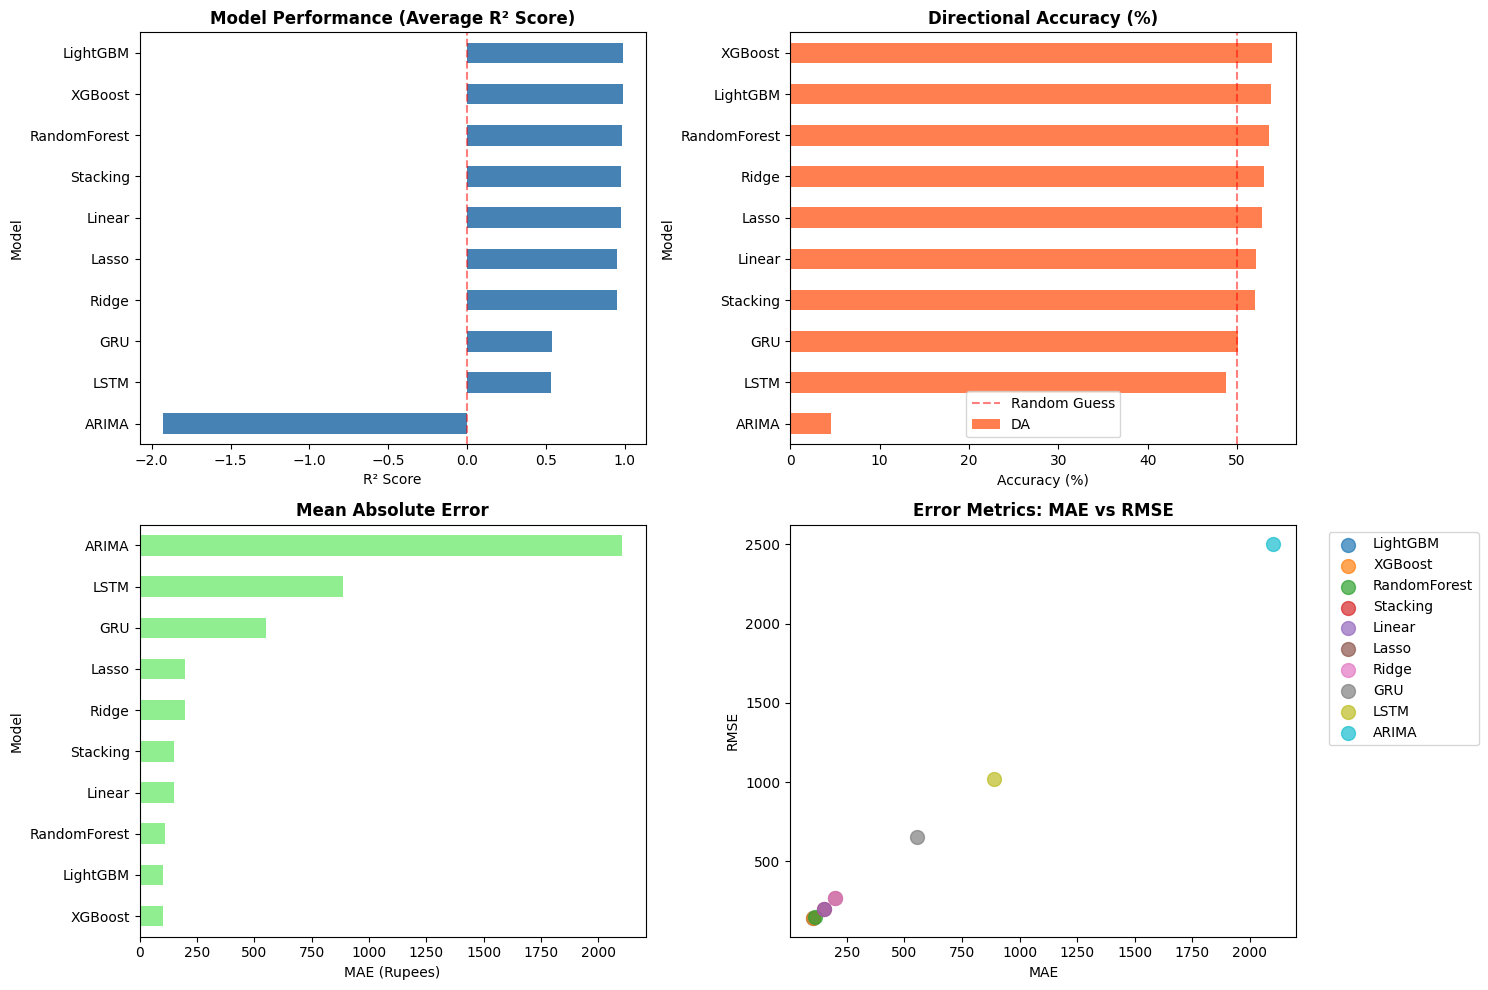

Final Analysis and Recommendations:

Best model by r-squared score: LightGBM
Best model by directional accuracy: XGBoost
Most robust model (lowest variance across splits): LightGBM

Models with acceptable performance (R² > 0.3):
                  R2       DA
Model                        
LightGBM      0.9878  53.7970
XGBoost       0.9878  53.9310
RandomForest  0.9865  53.5099
Stacking      0.9774  52.0136
Linear        0.9772  52.0971
Lasso         0.9545  52.7871
Ridge         0.9520  53.0575
GRU           0.5371  50.1398
LSTM          0.5359  48.7380


In [54]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
avg_results['R2'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Model Performance (Average R² Score)', fontsize=12, fontweight='bold')
ax.set_xlabel('R² Score')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

ax = axes[0, 1]
avg_results['DA'].sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('Directional Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='Random Guess')
ax.legend()

ax = axes[1, 0]
avg_results['MAE'].sort_values().plot(kind='barh', ax=ax, color='lightgreen')
ax.set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
ax.set_xlabel('MAE (Rupees)')

ax = axes[1, 1]
for model in avg_results.index:
    ax.scatter(avg_results.loc[model, 'MAE'], avg_results.loc[model, 'RMSE'], label=model, s=100, alpha=0.7)
ax.set_xlabel('MAE')
ax.set_ylabel('RMSE')
ax.set_title('Error Metrics: MAE vs RMSE', fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("Final Analysis and Recommendations:")
best_model_r2 = avg_results['R2'].idxmax()
best_model_da = avg_results['DA'].idxmax()
most_robust = variance_results['R2'].idxmin() if not variance_results.empty else "N/A"

print(f"\nBest model by r-squared score: {best_model_r2}")
print(f"Best model by directional accuracy: {best_model_da}")
print(f"Most robust model (lowest variance across splits): {most_robust}")

good_models = avg_results[avg_results['R2'] > 0.3]
if not good_models.empty:
    print(f"\nModels with acceptable performance (R² > 0.3):")
    print(good_models[['R2', 'DA']].round(4))